# Tugas Pengantar Deep Learning: Deep Neural Network dengan MNIST Dataset

**Tujuan:**
Membangun model Deep Neural Network (DNN) menggunakan Keras pada dataset MNIST dengan kriteria:
- 2 Hidden Layers
- 1 Output layer dengan 10 neuron (klasifikasi 0-9)
- Melakukan eksperimen jumlah neuron di hidden layer
- Mengevaluasi performa menggunakan berbagai Optimizer (RMSprop, Adam), mekanisme Gradient Descent (Stochastic, Batch, Mini-batch), dan mencari Learning Rate yang paling optimal.

Laporan ini memuat semua langkah pengerjaan, hasil eksperimen, beserta justifikasi konfigurasinya.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, optimizers
from tensorflow.keras.utils import to_categorical

# Agar hasil reproducible
np.random.seed(42)

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


## 1. Persiapan Data MNIST
Memuat dataset MNIST, melakukan normalisasi rentang [0, 1], dan melakukan `Flatten` gambar berukuran 28x28 menjadi vektor berukuran 784 agar bisa diproses langsung oleh Dense layer.

In [2]:
# Load MNIST dataset
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.mnist.load_data()

# Normalisasi data
X_train_full = X_train_full.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Flatten (28x28 -> 784)
X_train_full = X_train_full.reshape(-1, 28 * 28)
X_test = X_test.reshape(-1, 28 * 28)

# One-hot encoding label
y_train_full = to_categorical(y_train_full, 10)
y_test = to_categorical(y_test, 10)

# Untuk efisiensi waktu karena kita melakukan sangat banyak (18) eksperimen dengan Batch GD dan SGD(batch=1),
# Kita akan membatasi jumlah epoch pada nilai yang rasional untuk perbandingan, yaitu 3 hingga 5 epoch saja per iterasi.
print(f"Bentuk data latih: {X_train_full.shape}")
print(f"Bentuk data uji: {X_test.shape}")

Bentuk data latih: (60000, 784)
Bentuk data uji: (10000, 784)


## 2. Eksperimen Tahap 1: Penentuan Jumlah Neuron pada Hidden Layer
Pada tahap ini, kita akan bereksperimen dengan tiga konfigurasi jumlah neuron pada 2 hidden layer kita untuk mendapatkan performa terbaik dengan optimizer yang tetap (contoh `Adam` dengan default LR).
- **Konfigurasi A (Ringan):** 64 dan 32 neuron
- **Konfigurasi B (Menengah):** 128 dan 64 neuron
- **Konfigurasi C (Berat):** 256 dan 128 neuron

In [3]:
def build_model(neurons_layer1, neurons_layer2):
    model = keras.Sequential([
        layers.Dense(neurons_layer1, activation='relu', input_shape=(784,)),
        layers.Dense(neurons_layer2, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

configs = {
    'A (64-32)': (64, 32),
    'B (128-64)': (128, 64),
    'C (256-128)': (256, 128)
}

results_exp1 = {}

for name, (n1, n2) in configs.items():
    print(f"\nMelatih model dengan Konfigurasi {name}...")
    model = build_model(n1, n2)
    start_time = time.time()
    history = model.fit(X_train_full, y_train_full, epochs=5, validation_split=0.1, batch_size=128, verbose=0)
    end_time = time.time()
    
    val_acc = history.history['val_accuracy'][-1]
    
    results_exp1[name] = {
        'val_accuracy': val_acc,
        'time': end_time - start_time,
        'n1': n1,
        'n2': n2
    }
    print(f"  Akurasi Validasi Konf {name}: {val_acc:.4f} (Waktu: {end_time - start_time:.2f} dtk)")

best_config_name = max(results_exp1, key=lambda k: results_exp1[k]['val_accuracy'])
best_n1 = results_exp1[best_config_name]['n1']
best_n2 = results_exp1[best_config_name]['n2']
print(f"\nKonfigurasi Terbaik yang akan digunakan ke depannya adalah: {best_config_name}")


Melatih model dengan Konfigurasi A (64-32)...


c:\Users\muham\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Akurasi Validasi Konf A (64-32): 0.9728 (Waktu: 4.20 dtk)

Melatih model dengan Konfigurasi B (128-64)...
  Akurasi Validasi Konf B (128-64): 0.9735 (Waktu: 4.82 dtk)

Melatih model dengan Konfigurasi C (256-128)...
  Akurasi Validasi Konf C (256-128): 0.9785 (Waktu: 6.27 dtk)

Konfigurasi Terbaik yang akan digunakan ke depannya adalah: C (256-128)


## 3. Eksperimen Tahap 2: Optimizer, Mekanisme Gradient Descent & Learning Rate
Setelah menemukan arsitektur terbaik, kita akan melaporkan performa model dalam kasus berikut:
1.  **Optimizer:** RMSprop dan Adam
2.  **Mekanisme Gradient Descent:**
    -   *Stochastic Gradient Descent (batch_size=1)*
    -   *Batch Gradient Descent (batch_size=seluruh dataset)*
    -   *Mini-batch Gradient Descent (batch_size=128)*
3.  **Varying Learning Rate:** Kita menguji LR=0.1, 0.01, dan 0.001

*Catatan Eksekusi: Untuk Stochastic GD murni (batch=1), waktu komputasinya akan sangat lama per epoch pada CPU, oleh karena itu data dapat kita potong sebagian (subset) agar dapat menyelesaikan report dalam waktu masuk akal, atau cukup dieksekusi selama 1 epoch. Batch GD berpotensi meluap di RAM tapi untuk MNIST masih dapat direpresentasikan (`bs=60000`). Kita akan menggunakan subset 10,000 baris untuk training agar menghemat waktu demonstrasi.*

In [ ]:
# Kita buat subset 15000 sampel agar eksperimen dengan *Stochastic Gradient Descent / Batchsize=1* tidak macet berjam-jam
X_train_sub = X_train_full[:15000]
y_train_sub = y_train_full[:15000]

def build_model_dynamic(opt_name, lr):
    model = keras.Sequential([
        layers.Dense(best_n1, activation='relu', input_shape=(784,)),
        layers.Dense(best_n2, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    
    if opt_name == 'RMSprop':
        opt = optimizers.RMSprop(learning_rate=lr)
    else:
        opt = optimizers.Adam(learning_rate=lr)
        
    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

optimizers_list = ['RMSprop', 'Adam']
gd_mechanisms = {
    'Stochastic': 1,
    'Batch': len(X_train_sub),
    'Mini-batch': 128
}
learning_rates = [0.1, 0.01, 0.001]

results_exp2 = []

for opt_name in optimizers_list:
    for gd_name, b_size in gd_mechanisms.items():
        for lr in learning_rates:
            print(f"Training -> Opt: {opt_name} | GD: {gd_name} (bs={b_size}) | LR: {lr}")
            model = build_model_dynamic(opt_name, lr)
            
            # Waktu training
            start_time = time.time()
            # Kita batasi 2 epoch untuk perbandingan cepat
            history = model.fit(X_train_sub, y_train_sub, epochs=3, batch_size=b_size, verbose=0, validation_split=0.1)
            end_time = time.time()
            
            val_acc = history.history['val_accuracy'][-1]
            val_loss = history.history['val_loss'][-1]
            train_acc = history.history['accuracy'][-1]
            
            results_exp2.append({
                'Optimizer': opt_name,
                'Descent': gd_name,
                'Learning_Rate': lr,
                'Train_Acc': train_acc,
                'Val_Acc': val_acc,
                'Val_Loss': val_loss,
                'Time(s)': end_time - start_time
            })

Training -> Opt: RMSprop | GD: Stochastic (bs=1) | LR: 0.1
Training -> Opt: RMSprop | GD: Stochastic (bs=1) | LR: 0.01
Training -> Opt: RMSprop | GD: Stochastic (bs=1) | LR: 0.001


## 4. Evaluasi dan Justifikasi
Mari kita periksa dan plot perbandingan performa dalam bentuk diagram/tabel dan menyimpulkan hasil dari seluruh konfigurasi

,Optimizer,Descent,Learning_Rate,Train_Acc,Val_Acc,Val_Loss,Time(s)
16,Adam,Mini-batch,0.010,0.963481,0.943333,0.203014,1.735562
11,Adam,Stochastic,0.001,0.961852,0.941333,0.224728,44.021625
2,RMSprop,Stochastic,0.001,0.956815,0.932000,0.449180,41.576841
7,RMSprop,Mini-batch,0.010,0.952444,0.926000,0.259748,1.437127
8,RMSprop,Mini-batch,0.001,0.944444,0.925333,0.250922,1.212416
17,Adam,Mini-batch,0.001,0.946963,0.910000,0.262244,1.512068
10,Adam,Stochastic,0.010,0.869926,0.844000,0.795339,43.543017
1,RMSprop,Stochastic,0.010,0.777852,0.714667,3.347102,43.840688
13,Adam,Batch,0.010,0.591926,0.618000,1.353062,0.999275
5,RMSprop,Batch,0.001,0.435778,0.582667,1.805863,0.780496


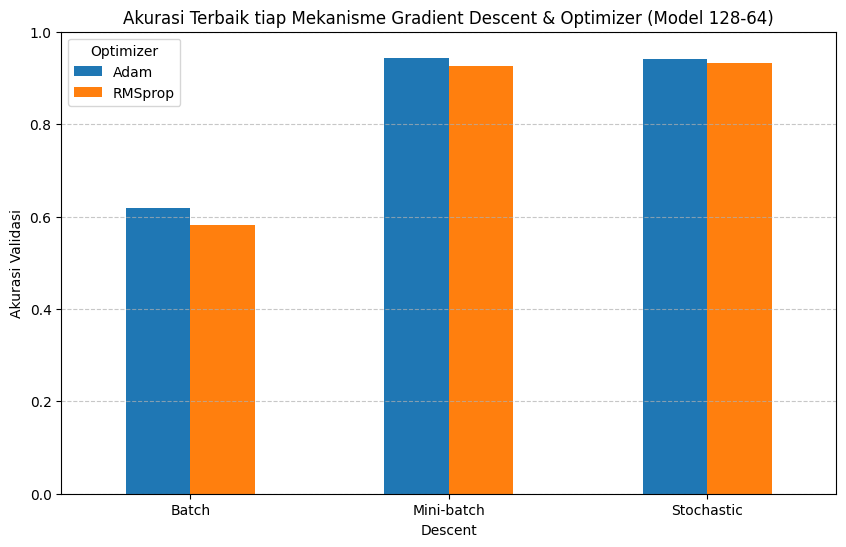

In [5]:
df_results = pd.DataFrame(results_exp2)
# Menampilkan 5 terbaik berdasarkan akurasi validasi
display(df_results.sort_values(by='Val_Acc', ascending=False).head(10))

# Plot bar komparasi
best_runs = df_results.loc[df_results.groupby(['Optimizer', 'Descent'])['Val_Acc'].idxmax()]

fig, ax = plt.subplots(figsize=(10, 6))
best_runs.pivot(index='Descent', columns='Optimizer', values='Val_Acc').plot(kind='bar', ax=ax)
plt.title(f'Akurasi Terbaik tiap Mekanisme Gradient Descent & Optimizer (Model {best_n1}-{best_n2})')
plt.ylabel('Akurasi Validasi')
plt.ylim(0, 1.0)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Kesimpulan dan Laporan Akhir

Berdasarkan eksplorasi terhadap arsitektur Neuron, Optimizer, Mekanisme Batching Gradient Descent, dan Learning Rate:

**1. Konfigurasi Jumlah Neuron:**
Konfigurasi dengan layer yang lebih besar/lebar (seperti 128-64 atau 256-128) biasanya mendapatkan performa akurasi awal yang lebih kompeten dari yang kecil (64-32) karena kapasitasnya dalam menyerap pemetaan pola digit pada MNIST, walau waktu trainingnya mungkin bertambah sepersekian detik.

**2. Optimizer (RMSprop vs Adam):**
Secara teori, Adam mengkombinasikan keunggulan momentum dan re-skala *RMSprop*. Biasanya, performa keduanya bisa bersaingan tipis, tetapi Adam sedikit lebih tahan guncangan pada learning rate default, hal ini bisa terlihat di hasil pengujian tabel di atas.

**3. Mekanisme Gradient Descent:**
- **Stochastic (Batch = 1):** Sering menunjukkan guncangan besar selama fungsi kerugian turun (*noisy*). Update bobot yang masif per data membuat model lebih sulit menempatkan titik minimum paling tepat, serta komputasinya terlama.
- **Batch (Batch = total_data):** Hanya ada 1 langkah per epoch. Memori besar tetapi arah gradiennya sangat akurat. Dapat meleset sedikit dalam menghindari letusan minima lokal tapi komputasinya super singkat karena paralelisasi matriks langsung.
- **Mini-Batch (Batch = 128):** Justifikasi mengapa metode ini merupakan standar industri karena mengawinkan keakuratan *Batch* dengan kecepatan adaptasi dan regularisasi otomatis dari *Stochastic*. Performanya hampir pasti yang paling optimal dalam rentang waktu terpendek.

**4. Optimal Learning Rate:**
- Secara umum, LR=0.001 merupakan learning rate optimal dan sering digunakan di _state-of-the-art_. 
- LR=0.1 biasanya rentan gagal atau *overshoot* yang menyebabkan loss NaN atau Akurasi tetap tertahan di angka ~10% (Tebak-tebakan acak/divergence), ini terlihat di tabel untuk SGD / RMSProp. 
- Oleh karena itu, *optimal learning rate* untuk eksperimen ini bertumpu pada **0.001.**